<a href="https://colab.research.google.com/github/theapanday-lab/Data_Analytics_Subject/blob/main/panday_activity_2_data_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [2]:
path = kagglehub.dataset_download("danielcorredera/student-mat-csv")
print ("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-mat-csv' dataset.
Path to dataset files: /kaggle/input/student-mat-csv


In [3]:
print(os.listdir(path))

['student-mat.csv']


In [4]:
file_path = os.path.join(path, "student-mat.csv")
df = pd.read_csv(file_path, sep=";")

In [5]:
df


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [6]:
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [8]:
print("Number of Rows: ", df.shape[0])
print("Number of Columns: ", df.shape[1])

Number of Rows:  395
Number of Columns:  33


In [9]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [11]:
print("Average final grade: ", df["G3"].mean())

Average final grade:  10.415189873417722


In [12]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [13]:
print(df["sex"].value_counts())

sex
F    208
M    187
Name: count, dtype: int64


In [14]:
print(df["school"].value_counts())

school
GP    349
MS     46
Name: count, dtype: int64


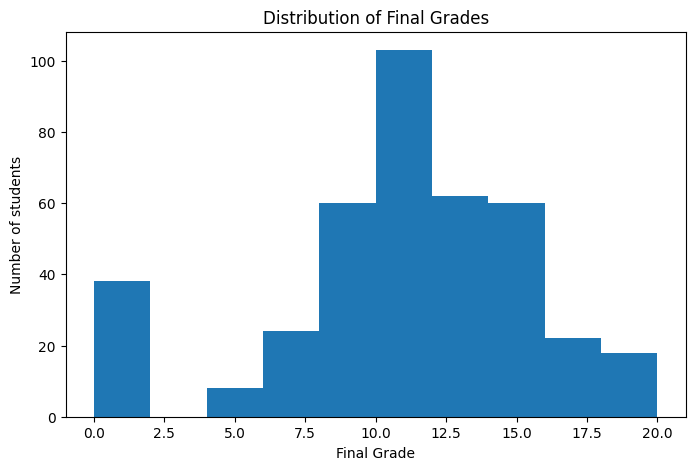

In [15]:
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)

plt.xlabel("Final Grade")
plt.ylabel("Number of students")
plt.title("Distribution of Final Grades")

plt.show()

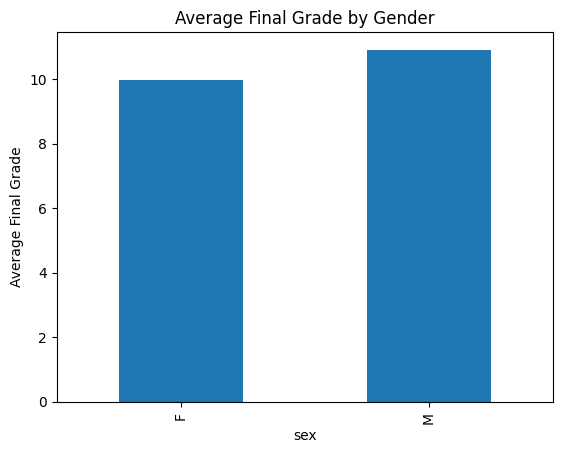

In [16]:
df.groupby("sex")["G3"].mean().plot(kind="bar")

plt.xlabel("sex")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Gender")

plt.show()

Diagnostic Analytix

In [17]:
df.groupby("studytime")["G3"].mean()


,G3
studytime,
1,10.047619
2,10.171717
3,11.400000
4,11.259259


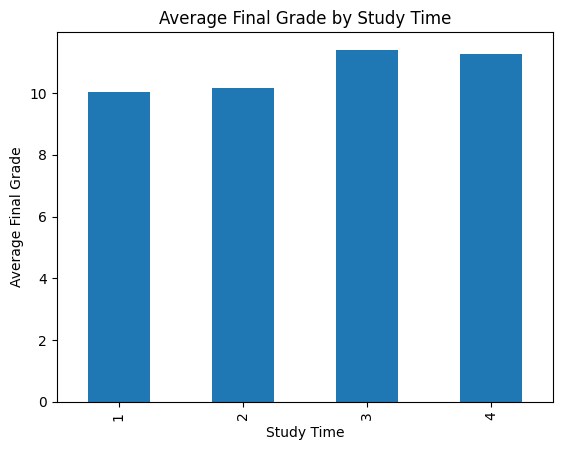

In [18]:
df.groupby("studytime") ["G3"].mean().plot(kind="bar")
plt.xlabel("Study Time")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Study Time")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["absences"], df["G3"])

plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs Final Grade")

plt.show()

In [ ]:
print((df["absences"]).corr(df["G3"]))


Prepare for Predictive Analytics


In [ ]:
df["pass"] = (df["G3"]>=10).astype(int)

In [ ]:
print(df["pass"].value_counts())

In [ ]:
features = [
    "age",
    "studytime",
    "failures",
    "G1",
    "G2"
]

x = df[features]
y = df["pass"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(x_train, y_train)

In [ ]:
y_pred = model.predict(x_test)

print(y_pred)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: ", accuracy)

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay( confusion_matrix=cm, display_labels=["Fail" , "Pass"])
disp.plot()

plt.title("Student Pass/Fail Confution Matrix")
plt.show()

prediction result table


In [ ]:
results = x_test.copy()

results["Actual"]=y_test
results["Predicted"]=y_pred

results.head(10)

prescritive

In [ ]:
results["Risk"] = results["Predicted"].map({

0: "Prioritize for academic intervertion",
1: "Continue Regular Monitoring"


})

results.head(10)

In [ ]:
probabilities = model.predict_proba(x_test)

results["Probability_of_Failing"]=probabilities[:,0]

results.sort_values(
    "Probability_of_Failing",
    ascending=False,

).head(20)



In [ ]:
priority_students=results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(20)

priority_students
